# Image Compression & Reconstruction using Autoencoders
### Exploring ANN and CNN Architectures with Varying Bottleneck Sizes

**Pipeline:**
```
Input Image → Encoder → Latent Space (Bottleneck) → Decoder → Reconstructed Image
```

**Models Implemented:**
- ANN-AutoEncoder-v1 : Shallow ANN (bottleneck=64)
- ANN-AutoEncoder-v2 : Deep ANN with BN + Dropout (bottleneck=32)
- CNN-AutoEncoder-v1 : Lightweight CNN (bottleneck=64)
- CNN-AutoEncoder-v2 : Deep CNN with LeakyReLU (bottleneck=32)

**Dataset:** EMNIST Letters — 88,800 train / 14,800 test, 26 classes, 28×28 grayscale

## 0. Setup & Imports

In [1]:


import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision

import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 18 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.9.0+cu126


## 1. Dataset Loading

In [2]:

DATA_DIR  = '/kaggle/input/datasets/crawford/emnist'
TRAIN_CSV = f'{DATA_DIR}/emnist-letters-train.csv'
TEST_CSV  = f'{DATA_DIR}/emnist-letters-test.csv'

assert os.path.exists(DATA_DIR), f"Dataset folder not found: '{DATA_DIR}'"
print(f'Dataset folder found: {DATA_DIR}')


IMG_SIZE   = 28
BATCH_SIZE = 32
EPOCHS     = 40
LR         = 1e-3


print('Loading CSVs...')
train_df = pd.read_csv(TRAIN_CSV, header=None)
test_df  = pd.read_csv(TEST_CSV,  header=None)
print(f'Train rows: {len(train_df)}  |  Test rows: {len(test_df)}')

def df_to_tensor(df):
    
    labels = torch.tensor(df.iloc[:, 0].values, dtype=torch.long)
    pixels = torch.tensor(df.iloc[:, 1:].values, dtype=torch.float32) / 255.0
    # EMNIST CSVs are stored transposed — fix orientation
    imgs = pixels.view(-1, 1, 28, 28).transpose(2, 3).flip(3)
    return imgs, labels

train_imgs, train_labels = df_to_tensor(train_df)
test_imgs,  test_labels  = df_to_tensor(test_df)

# Train / Val split (85/15)
val_size   = int(len(train_imgs) * 0.15)
train_size = len(train_imgs) - val_size
indices    = torch.randperm(len(train_imgs),
                            generator=torch.Generator().manual_seed(SEED))

train_ds = TensorDataset(train_imgs[indices[:train_size]],
                         train_labels[indices[:train_size]])
val_ds   = TensorDataset(train_imgs[indices[train_size:]],
                         train_labels[indices[train_size:]])
test_ds  = TensorDataset(test_imgs, test_labels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'\nTrain : {train_size}')
print(f'Val   : {val_size}')
print(f'Test  : {len(test_imgs)}')
print(f'Image shape : {train_imgs[0].shape}')
print(f'Pixel range : [{train_imgs.min():.1f}, {train_imgs.max():.1f}]')
print(f'Classes     : {train_labels.unique().numel()} letters')

Dataset folder found: /kaggle/input/datasets/crawford/emnist
Loading CSVs...
Train rows: 88800  |  Test rows: 14800

Train : 75480
Val   : 13320
Test  : 14800
Image shape : torch.Size([1, 28, 28])
Pixel range : [0.0, 1.0]
Classes     : 26 letters


## 2. Visualize Sample Images (Train & Test)

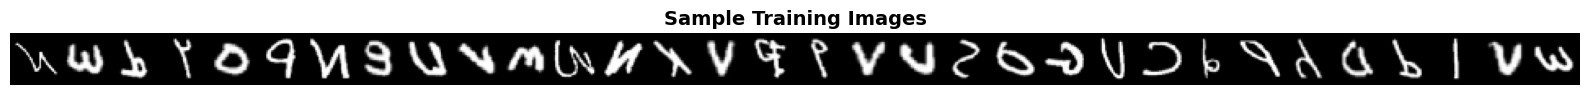

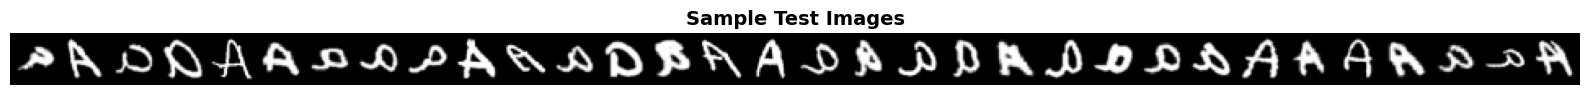

Batch shape : torch.Size([32, 1, 28, 28])
dtype       : torch.float32
Range       : [0.00, 1.00]


In [3]:
def show_images(imgs, title='Sample Images', nrow=32):
    imgs = imgs.cpu().clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs[:nrow], nrow=nrow, padding=2)
    plt.figure(figsize=(16, 2.5))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show samples from train and test
train_batch, _ = next(iter(train_loader))
test_batch,  _ = next(iter(test_loader))

show_images(train_batch, title='Sample Training Images')
show_images(test_batch,  title='Sample Test Images')

print(f'Batch shape : {train_batch.shape}')
print(f'dtype       : {train_batch.dtype}')
print(f'Range       : [{train_batch.min():.2f}, {train_batch.max():.2f}]')

## 3. Model Architectures
### 3.1 ANN Autoencoders (Fully Connected)

In [4]:

# ANN Autoencoder v1 — Shallow, Bottleneck=64            
# 784 → 256 → 64 → [64] → 64 → 256 → 784                
class ANNAutoencoder_v1(nn.Module):
    def __init__(self, img_size=28, in_channels=1, bottleneck=64):
        super().__init__()
        flat = img_size * img_size * in_channels   # 784(28 into 28 into 1)
        self.flat     = flat
        self.img_size = img_size
        self.in_ch    = in_channels

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(),
            nn.Linear(256,   64), nn.ReLU(),
            nn.Linear(64, bottleneck),             #  this the latent space
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 64),  nn.ReLU(),
            nn.Linear(64,  256),        nn.ReLU(),
            nn.Linear(256, flat),       nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z).view(-1, self.in_ch, self.img_size, self.img_size)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z



#  ANN Autoencoder v2 — Deep + BN + Dropout, BN=32        
#  784 → 512 → 128 → [32] → 128 → 512 → 784              
class ANNAutoencoder_v2(nn.Module):
    def __init__(self, img_size=28, in_channels=1, bottleneck=32):
        super().__init__()
        flat = img_size * img_size * in_channels   # 784(28 into 28 into 1)
        self.flat     = flat
        self.img_size = img_size
        self.in_ch    = in_channels

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512,  128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, bottleneck),                            # this the latent space
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128,  512),       nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512,  flat),      nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z).view(-1, self.in_ch, self.img_size, self.img_size)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


# Sanity check
dummy = torch.zeros(2, 1, 28, 28).to(DEVICE)
for name, model in [('ANN-v1 (BN=64)', ANNAutoencoder_v1()),
                    ('ANN-v2 (BN=32)', ANNAutoencoder_v2())]:
    model = model.to(DEVICE)
    out, z = model(dummy)
    print(f'{name} | latent: {z.shape} | output: {out.shape} | params: {sum(p.numel() for p in model.parameters()):,}')

ANN-v1 (BN=64) | latent: torch.Size([2, 64]) | output: torch.Size([2, 1, 28, 28]) | params: 443,856
ANN-v2 (BN=32) | latent: torch.Size([2, 32]) | output: torch.Size([2, 1, 28, 28]) | params: 946,736


### 3.2 CNN Autoencoders (Convolutional)

In [5]:
#  CNN Autoencoder v1 — Lightweight, Bottleneck=64       
#  28 to 14 to 7 (conv)  to  FC(64)  to  FC  to  7 to 14 to 28 (deconv)      
class CNNAutoencoder_v1(nn.Module):
    def __init__(self, bottleneck=64):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),   # 28 to 14
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # 14 to 7
            nn.BatchNorm2d(32), nn.ReLU(),
        )
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, bottleneck),          # this the latent space
        )
        self.decoder_fc = nn.Sequential(
            nn.Linear(bottleneck, 32 * 7 * 7),
            nn.ReLU(),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 7 to 14
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16,  1, 4, stride=2, padding=1),  # 14 to 28
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder_fc(self.encoder_conv(x))

    def decode(self, z):
        return self.decoder_conv(self.decoder_fc(z).view(-1, 32, 7, 7))

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


#  CNN Autoencoder v2 — Deep + LeakyReLU, BN=32          
#  28 to 14 to 7 (2 conv blocks)  to  FC(128 to 32)  to  deconv back    
class CNNAutoencoder_v2(nn.Module):
    def __init__(self, bottleneck=32):
        super().__init__()

        def conv_block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, stride=2, padding=1),
                nn.BatchNorm2d(cout),
                nn.LeakyReLU(0.2),
            )

        def deconv_block(cin, cout):
            return nn.Sequential(
                nn.ConvTranspose2d(cin, cout, 4, stride=2, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(),
            )

        self.encoder_conv = nn.Sequential(
            conv_block(1,  32),   # 28 to 14
            conv_block(32, 64),   # 14 to 7
        )
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, bottleneck),              # this the latent space
        )
        self.decoder_fc = nn.Sequential(
            nn.Linear(bottleneck, 128), nn.ReLU(),
            nn.Linear(128, 64 * 7 * 7), nn.ReLU(),
        )
        self.decoder_conv = nn.Sequential(
            deconv_block(64, 32),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),   # 14 to 28
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder_fc(self.encoder_conv(x))

    def decode(self, z):
        return self.decoder_conv(self.decoder_fc(z).view(-1, 64, 7, 7))

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z




class CNNAutoencoder_v3_Skip(nn.Module):
    def __init__(self, bottleneck=32):
        super().__init__()

        # Encoder Layers
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28 -> 14
            nn.BatchNorm2d(16), nn.ReLU(),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14 -> 7
            nn.BatchNorm2d(32), nn.ReLU(),
        )

        # Bottleneck
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, bottleneck),
        )
        self.decoder_fc = nn.Sequential(
            nn.Linear(bottleneck, 32 * 7 * 7),
            nn.ReLU(),
        )

        # Decoder Layers (Notice cin is doubled for skip concatenation)
        self.dec1 = nn.Sequential(
            # Input is (bottleneck path: 32) + (skip path from enc2: 32) = 64
            nn.ConvTranspose2d(32 + 32, 16, 4, stride=2, padding=1), # 7 -> 14
            nn.BatchNorm2d(16), nn.ReLU(),
        )
        self.dec2 = nn.Sequential(
            # Input is (previous path: 16) + (skip path from enc1: 16) = 32
            nn.ConvTranspose2d(16 + 16, 1, 4, stride=2, padding=1),  # 14 -> 28
            nn.Sigmoid(),
        )

    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        z = self.encoder_fc(e2)
        return z

    def decode(self, z):
        
        d1_in = self.decoder_fc(z).view(-1, 32, 7, 7)
        # Pad with zeros where the skip connection usually goes
        d1 = self.dec1(torch.cat([d1_in, torch.zeros_like(d1_in)], dim=1))
        d2 = self.dec2(torch.cat([d1, torch.zeros_like(d1)], dim=1))
        return d2

    def forward(self, x):
        
        s1 = self.enc1(x)  
        s2 = self.enc2(s1) 
        z  = self.encoder_fc(s2)

        
        d1_in = self.decoder_fc(z).view(-1, 32, 7, 7)
        
        
        d1 = self.dec1(torch.cat([d1_in, s2], dim=1)) 
        
        
        d2 = self.dec2(torch.cat([d1, s1], dim=1))
        
        return d2, z

# Sanity check for all 3 CNN variants
dummy = torch.zeros(2, 1, 28, 28).to(DEVICE)

test_models = [
    ('CNN-v1 (BN=64)', CNNAutoencoder_v1(bottleneck=64)),
    ('CNN-v2 (BN=32)', CNNAutoencoder_v2(bottleneck=32)),
    ('CNN-v3 Skip (BN=32)', CNNAutoencoder_v3_Skip(bottleneck=32))
]

print(f'{"Model Name":<22} | {"Latent Shape":<15} | {"Output Shape":<18} | {"Parameters":<10}')
print('-' * 75)

for name, model in test_models:
    model = model.to(DEVICE)
    out, z = model(dummy)

    params = sum(p.numel() for p in model.parameters())
    
    print(f'{name:<22} | {str(list(z.shape)):<15} | {str(list(out.shape)):<18} | {params:,}')

Model Name             | Latent Shape    | Output Shape       | Parameters
---------------------------------------------------------------------------
CNN-v1 (BN=64)         | [2, 64]         | [2, 1, 28, 28]     | 215,729
CNN-v2 (BN=32)         | [2, 32]         | [2, 1, 28, 28]     | 866,817
CNN-v3 Skip (BN=32)    | [2, 32]         | [2, 1, 28, 28]     | 123,793


## 4. Training

In [6]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR,
                model_name='model', scheduler_step=15):
    
    criterion = nn.MSELoss()   # reconstruction error
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=0.5)

    history = {'train_loss': [], 'val_loss': []}
    best_val, best_state = float('inf'), None

    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        running_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(DEVICE)
            
            optimizer.zero_grad()
            recon, _ = model(imgs) 
            loss = criterion(recon, imgs)
            loss.backward()        
            optimizer.step()       
            
            running_loss += loss.item() * imgs.size(0)
        
        train_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(DEVICE)
                recon, _ = model(imgs)
                val_loss += criterion(recon, imgs).item() * imgs.size(0)
        
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step()

        # Saving the best model version based on validation performance
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{model_name}] Epoch {epoch:3d}/{epochs} | '
                  f'Train: {train_loss:.6f} | Val: {val_loss:.6f}')

    # Restore the weights that gave the lowest validation loss
    model.load_state_dict(best_state)
    print(f'  → Best Val Loss: {best_val:.6f}\n')
    return history


# Define & train all variants
models = {
    'ANN-v1 (BN=48)':     ANNAutoencoder_v1(bottleneck=48).to(DEVICE),
    'ANN-v2 (BN=32)':     ANNAutoencoder_v2(bottleneck=32).to(DEVICE),
    'CNN-v1 (BN=64)':     CNNAutoencoder_v1(bottleneck=64).to(DEVICE),
    'CNN-v2 (BN=32)':     CNNAutoencoder_v2(bottleneck=32).to(DEVICE),
    'CNN-v3 Skip (BN=32)': CNNAutoencoder_v3_Skip(bottleneck=32).to(DEVICE)
}

histories = {}
for name, model in models.items():
    print(f'\n{"="*55}')
    print(f'  Training: {name}')
    print(f'{"="*55}')
    histories[name] = train_model(model, train_loader, val_loader,
                                  epochs=EPOCHS, model_name=name)

print('\nAll models trained successfully!')


  Training: ANN-v1 (BN=48)
[ANN-v1 (BN=48)] Epoch   1/40 | Train: 0.041213 | Val: 0.027654
[ANN-v1 (BN=48)] Epoch   5/40 | Train: 0.017197 | Val: 0.017260
[ANN-v1 (BN=48)] Epoch  10/40 | Train: 0.015121 | Val: 0.015227
[ANN-v1 (BN=48)] Epoch  15/40 | Train: 0.014028 | Val: 0.014241
[ANN-v1 (BN=48)] Epoch  20/40 | Train: 0.012256 | Val: 0.012527
[ANN-v1 (BN=48)] Epoch  25/40 | Train: 0.012076 | Val: 0.012340
[ANN-v1 (BN=48)] Epoch  30/40 | Train: 0.011966 | Val: 0.012314
[ANN-v1 (BN=48)] Epoch  35/40 | Train: 0.011275 | Val: 0.011615
[ANN-v1 (BN=48)] Epoch  40/40 | Train: 0.011215 | Val: 0.011572
  → Best Val Loss: 0.011565


  Training: ANN-v2 (BN=32)
[ANN-v2 (BN=32)] Epoch   1/40 | Train: 0.026080 | Val: 0.015896
[ANN-v2 (BN=32)] Epoch   5/40 | Train: 0.018141 | Val: 0.013017
[ANN-v2 (BN=32)] Epoch  10/40 | Train: 0.017279 | Val: 0.012772
[ANN-v2 (BN=32)] Epoch  15/40 | Train: 0.016767 | Val: 0.012352
[ANN-v2 (BN=32)] Epoch  20/40 | Train: 0.014952 | Val: 0.010622
[ANN-v2 (BN=32)] Ep

## 5. Loss Curves

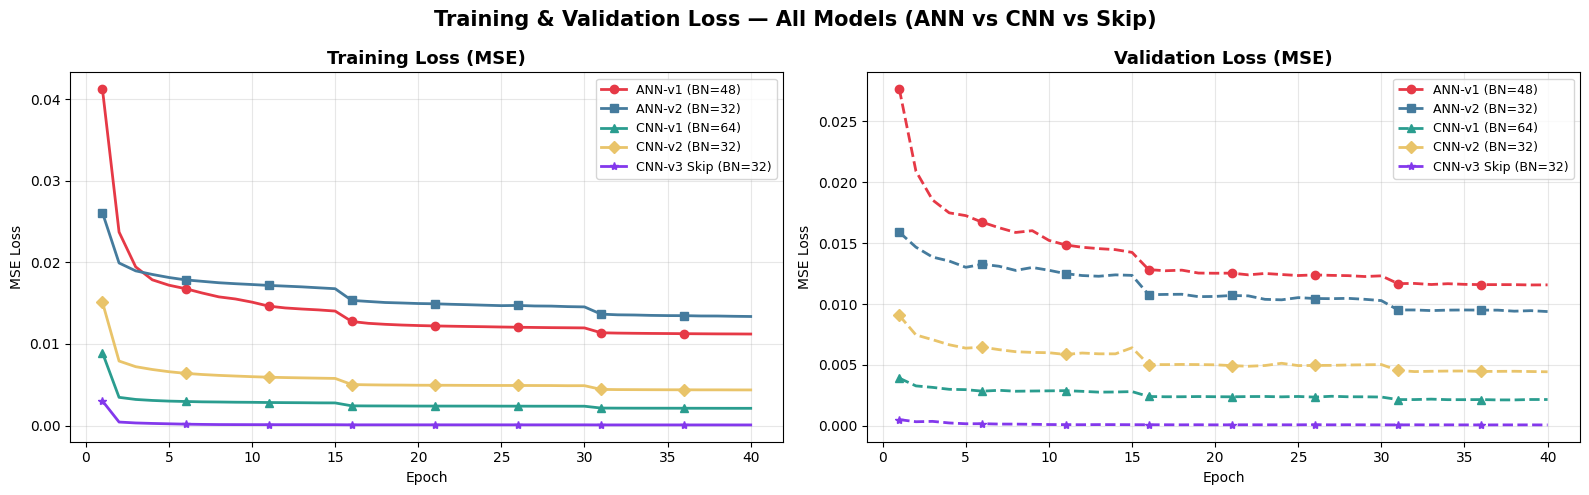


Model                   Final Train    Final Val     Best Val
--------------------------------------------------------------
ANN-v1 (BN=48)             0.011215     0.011572     0.011565
ANN-v2 (BN=32)             0.013364     0.009379     0.009379
CNN-v1 (BN=64)             0.002117     0.002152     0.002120
CNN-v2 (BN=32)             0.004368     0.004432     0.004432
CNN-v3 Skip (BN=32)        0.000082     0.000065     0.000065


In [7]:

COLORS  = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#8338EC']
MARKERS = ['o', 's', '^', 'D', '*']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for (name, hist), color, marker in zip(histories.items(), COLORS, MARKERS):
    ep = range(1, len(hist['train_loss']) + 1)
    
    # Training Loss Plot
    axes[0].plot(ep, hist['train_loss'], color=color, marker=marker,
                 markevery=5, label=name, linewidth=2)
    
    # Validation Loss Plot
    axes[1].plot(ep, hist['val_loss'],  color=color, marker=marker,
                 markevery=5, label=name, linewidth=2, linestyle='--')

for ax, title in zip(axes, ['Training Loss (MSE)', 'Validation Loss (MSE)']):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss — All Models (ANN vs CNN vs Skip)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table 
print(f'\n{"Model":<22} {"Final Train":>12} {"Final Val":>12} {"Best Val":>12}')
print('-' * 62)
for name, hist in histories.items():
    print(f'{name:<22} {hist["train_loss"][-1]:>12.6f} '
          f'{hist["val_loss"][-1]:>12.6f} '
          f'{min(hist["val_loss"]):>12.6f}')

## 6. Reconstruction Visualization — Train, Val & Test

Train Set Reconstructions


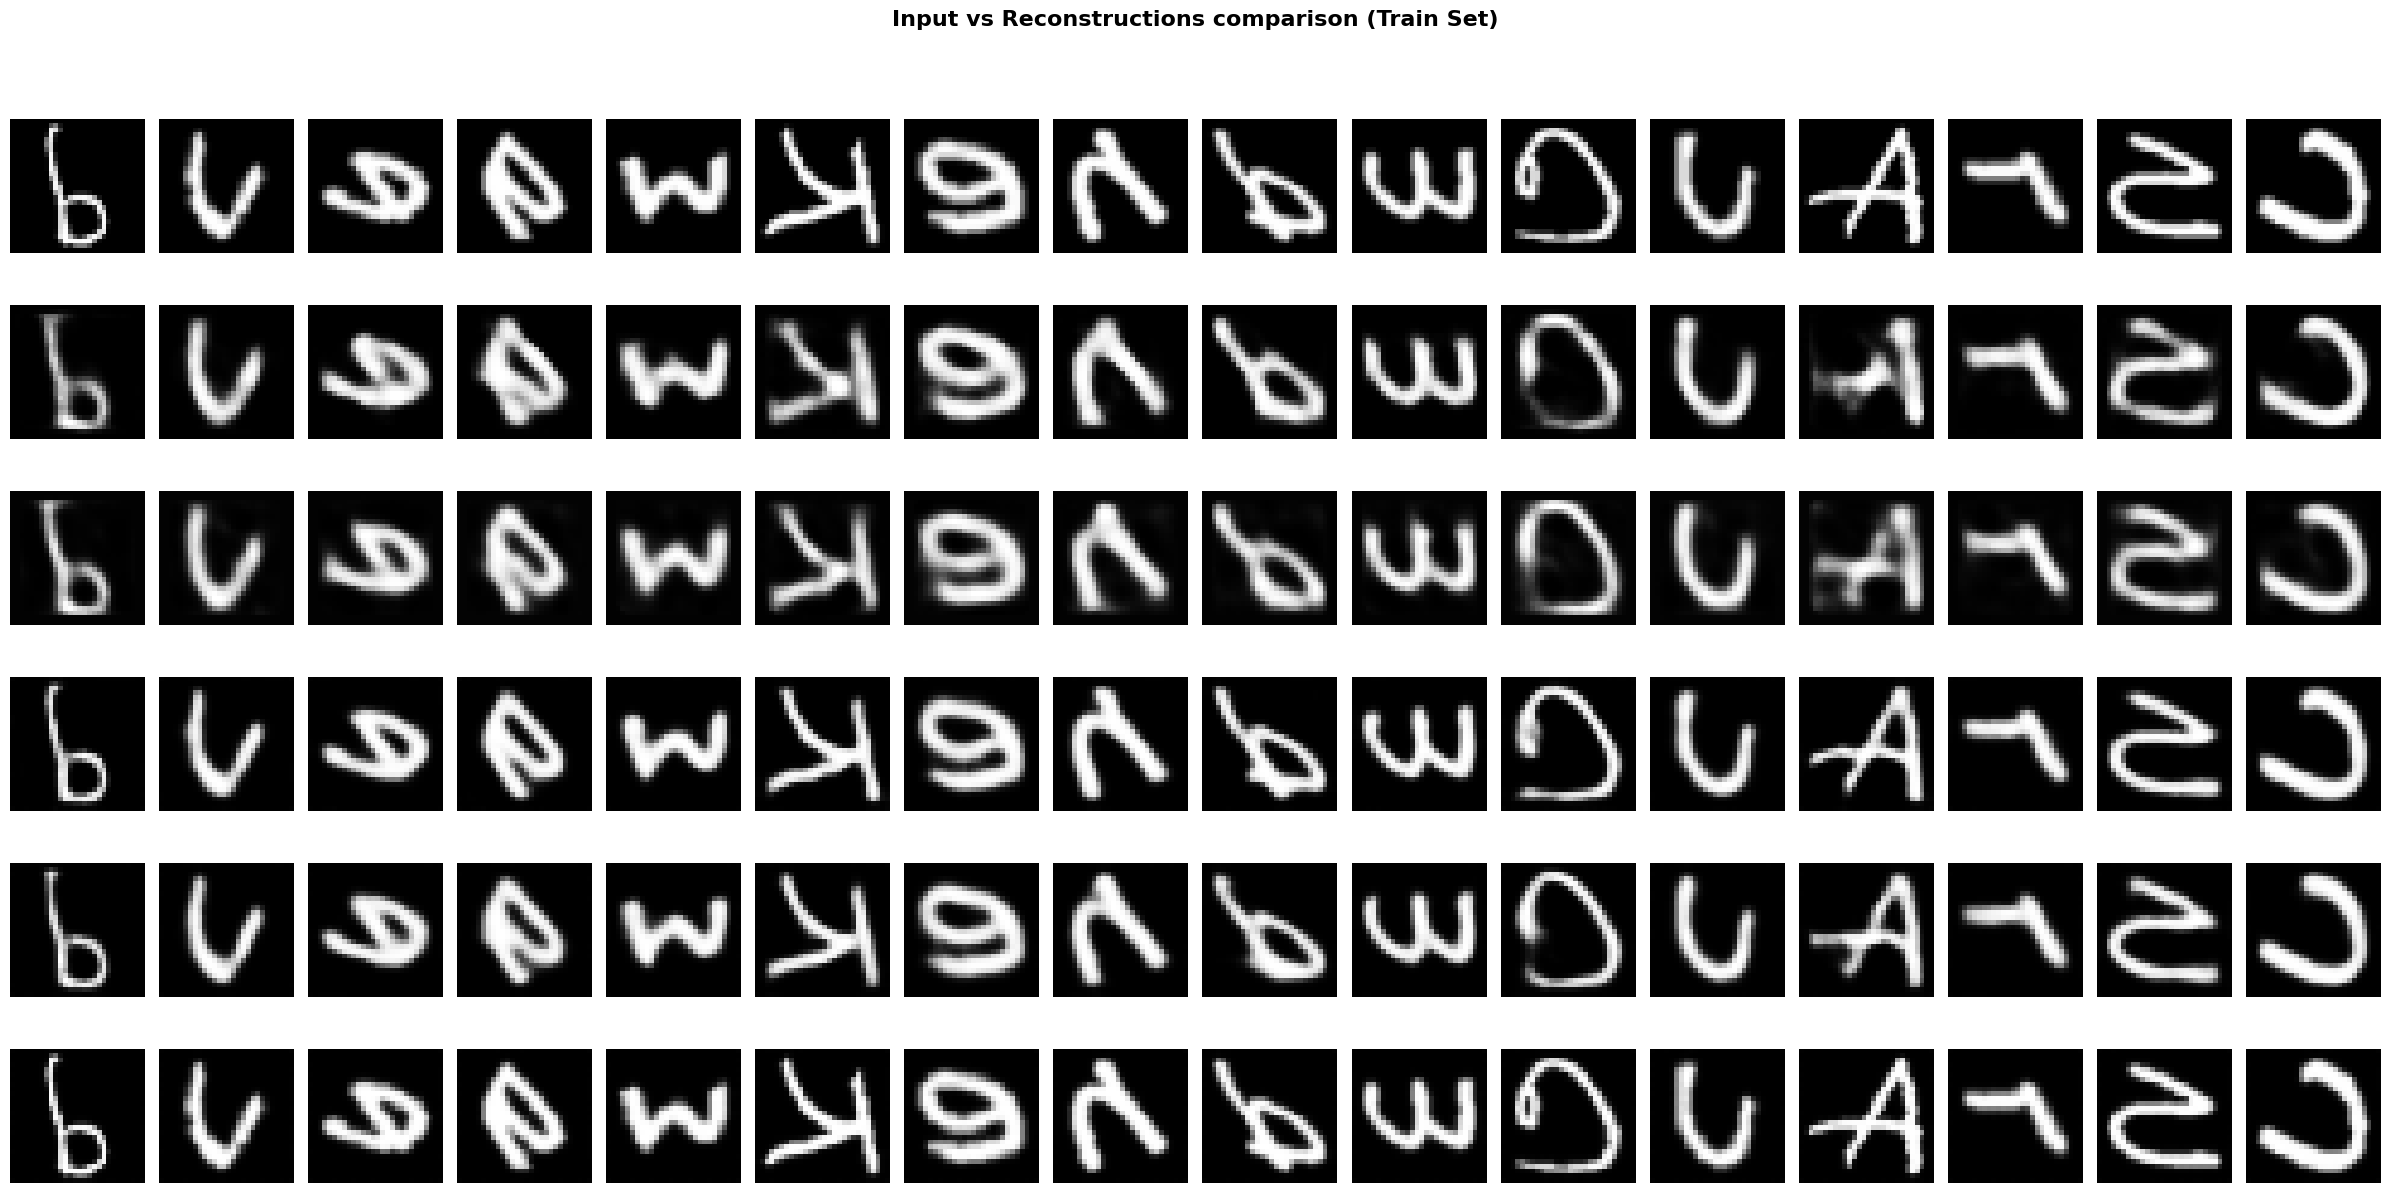

Validation Set Reconstructions


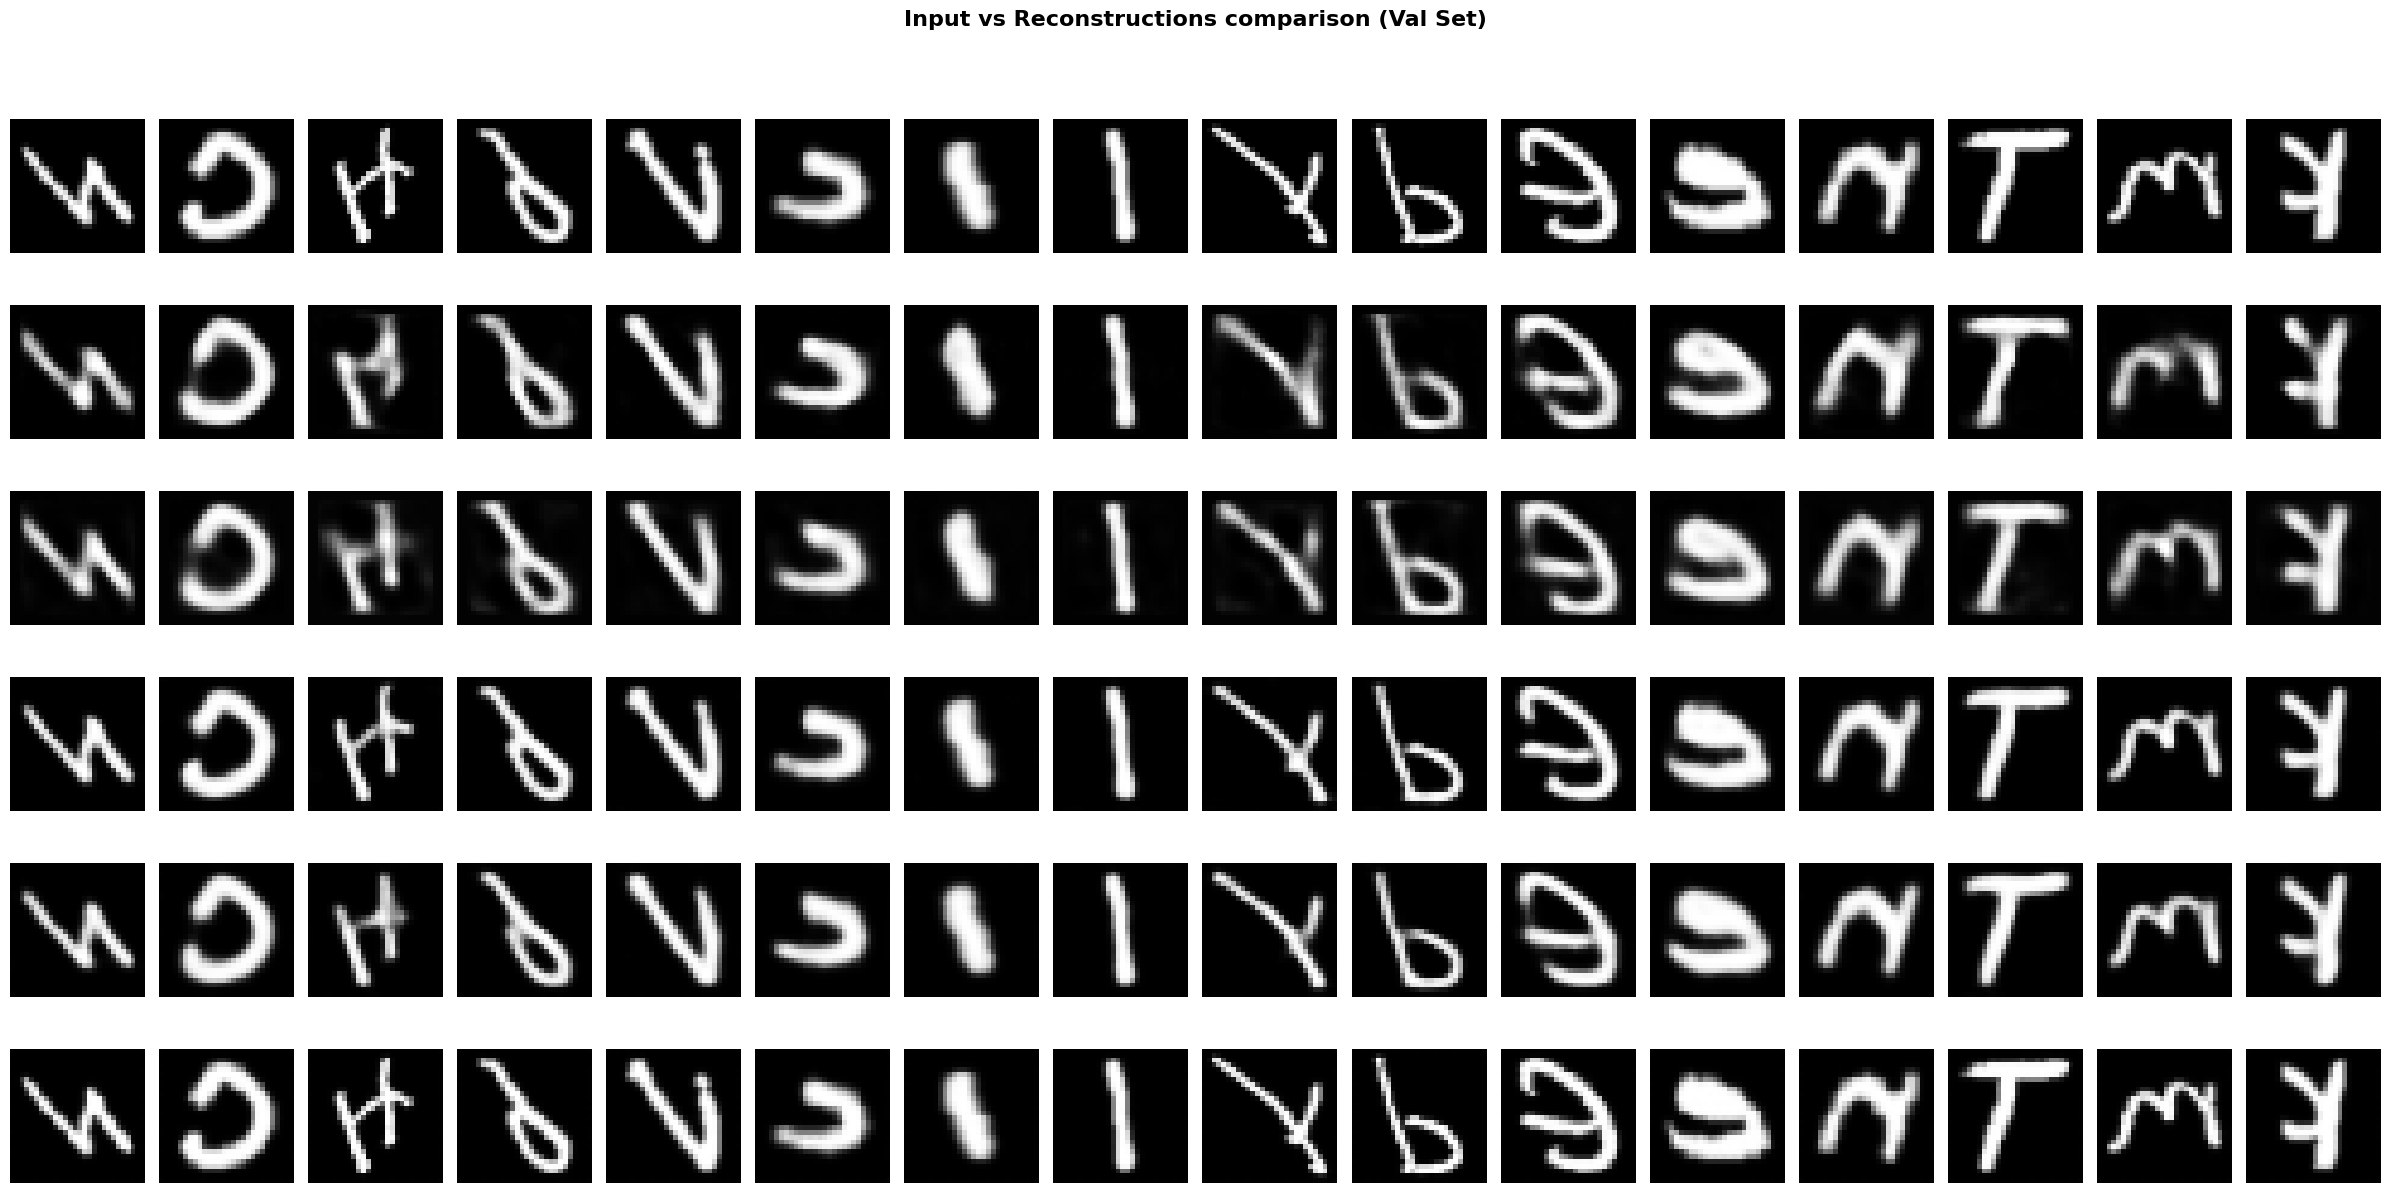

Test Set Reconstructions


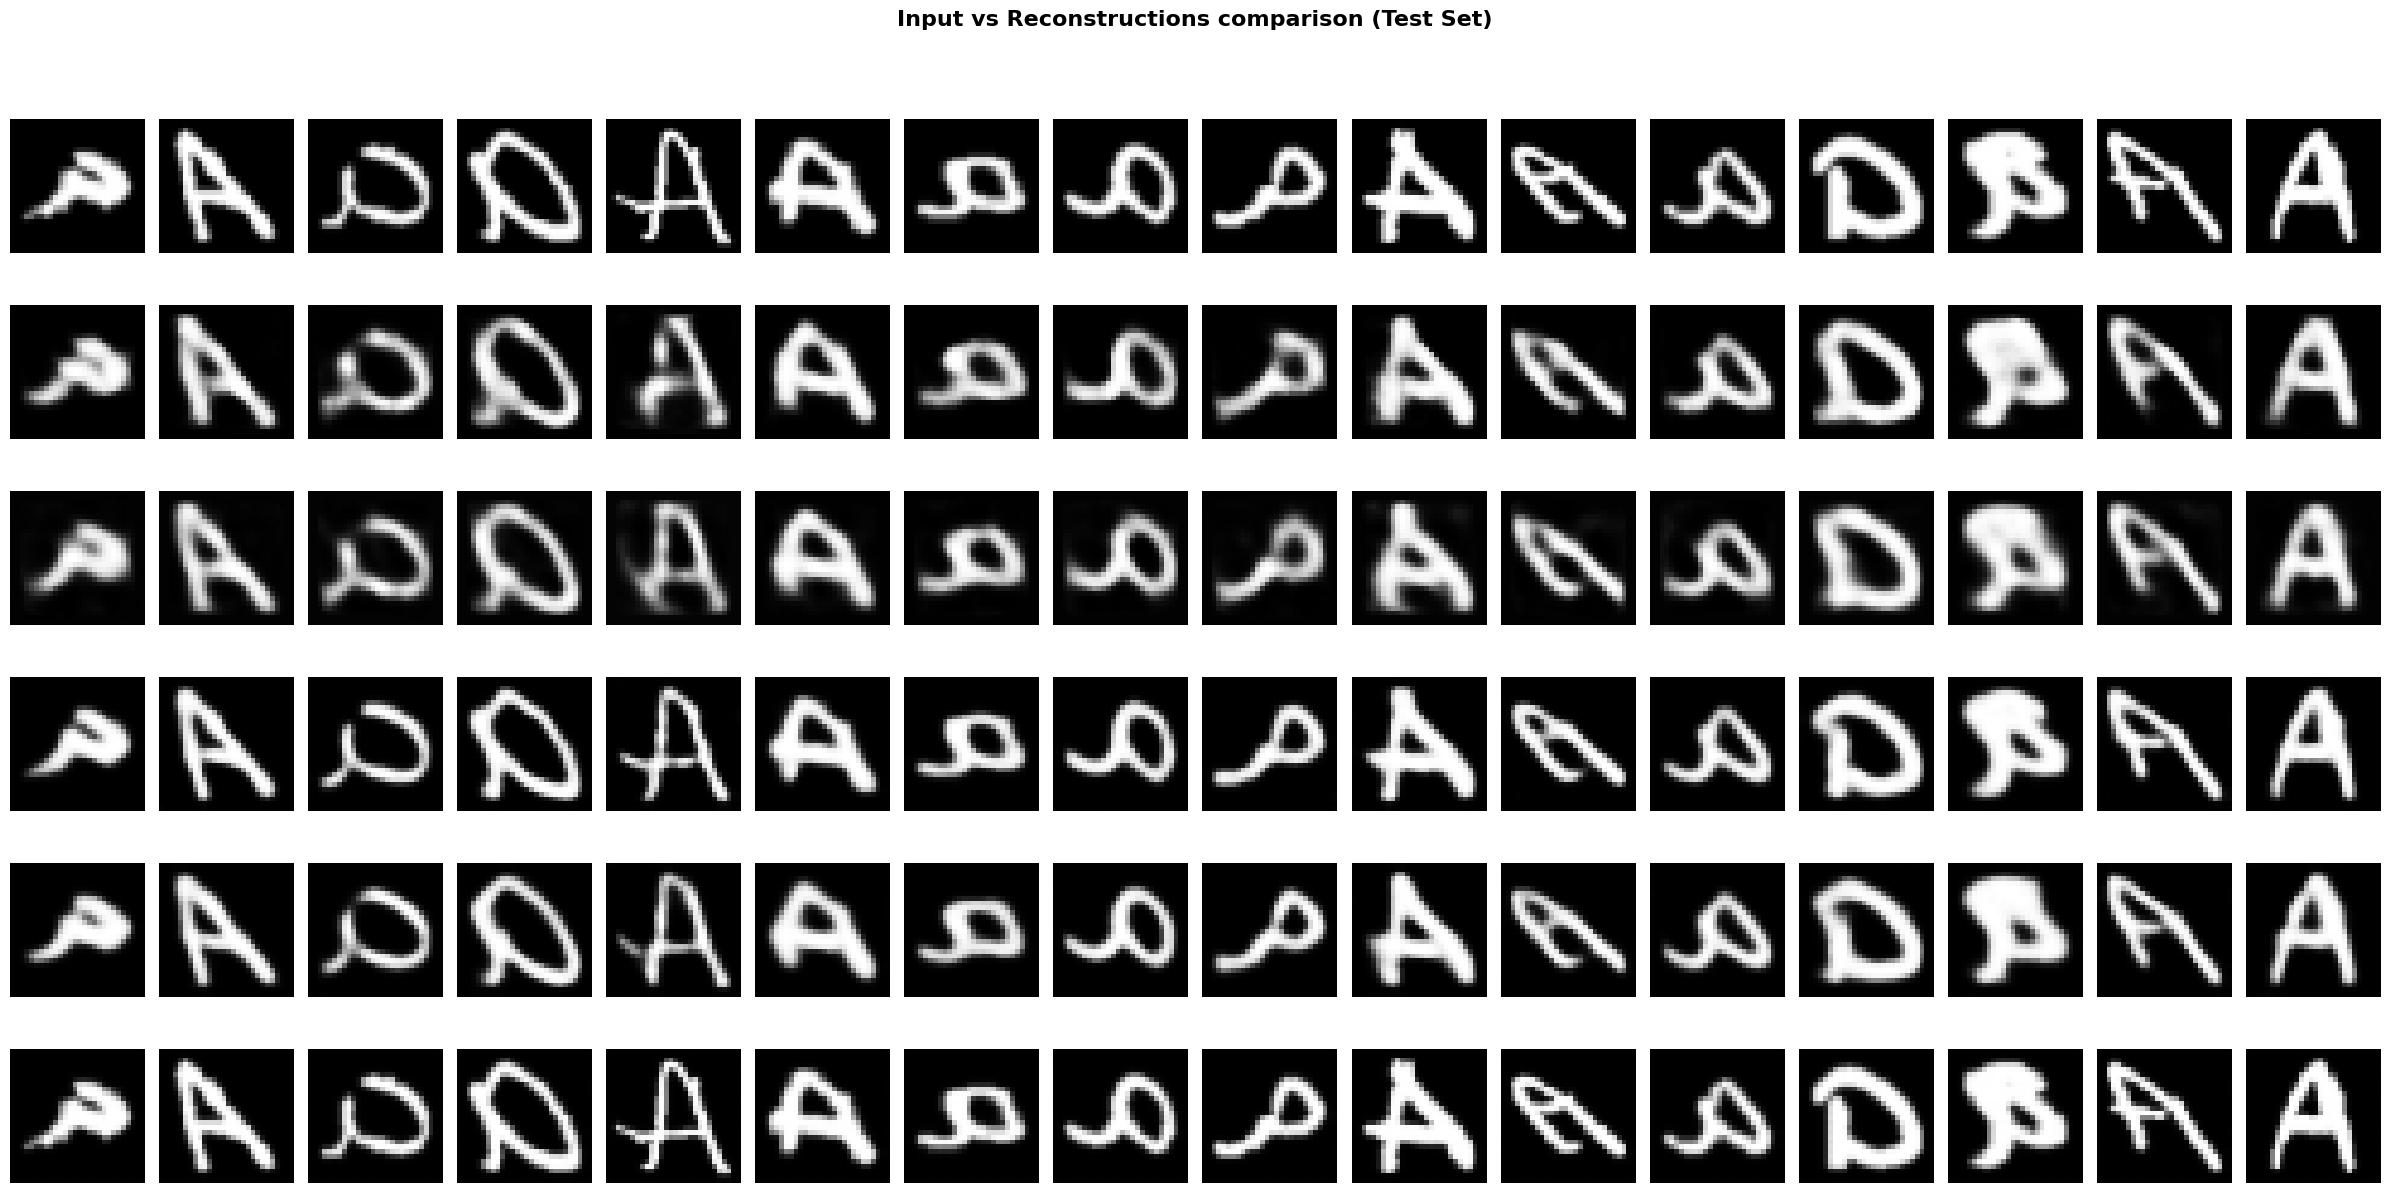

In [8]:
def visualize_reconstructions(models_dict, loader, n=16, split_name=''):
    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)

    n_models = len(models_dict)
    
    fig, axes = plt.subplots(n_models + 1, n, 
                             figsize=(n * 1.5, (n_models + 1) * 2.0))

    for j in range(n):
        axes[0, j].imshow(imgs[j].cpu().squeeze().numpy(), cmap='gray')
        axes[0, j].axis('off')
    
    axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, 
                           labelpad=50, va='center', fontweight='bold')

    for i, (name, model) in enumerate(models_dict.items(), start=1):
        model.eval()
        with torch.no_grad():
            recon, _ = model(imgs)
            
        recon = recon.cpu().clamp(0, 1)
        
        for j in range(n):
            axes[i, j].imshow(recon[j].squeeze().numpy(), cmap='gray')
            axes[i, j].axis('off')
        
        axes[i, 0].set_ylabel(name, fontsize=10, rotation=0, 
                               labelpad=55, va='center', fontweight='bold')

    title = f'Input vs Reconstructions comparison'
    if split_name:
        title += f' ({split_name} Set)'
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    fname = f'reconstructions_{split_name.lower()}.png' if split_name else 'reconstructions.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

print('Train Set Reconstructions')
visualize_reconstructions(models, train_loader, n=16, split_name='Train')

print('Validation Set Reconstructions')
visualize_reconstructions(models, val_loader,   n=16, split_name='Val')

print('Test Set Reconstructions')
visualize_reconstructions(models, test_loader,  n=16, split_name='Test')

## 7. Latent Space Visualization — Val & Test (PCA + t-SNE)

 Latent Space PCA 


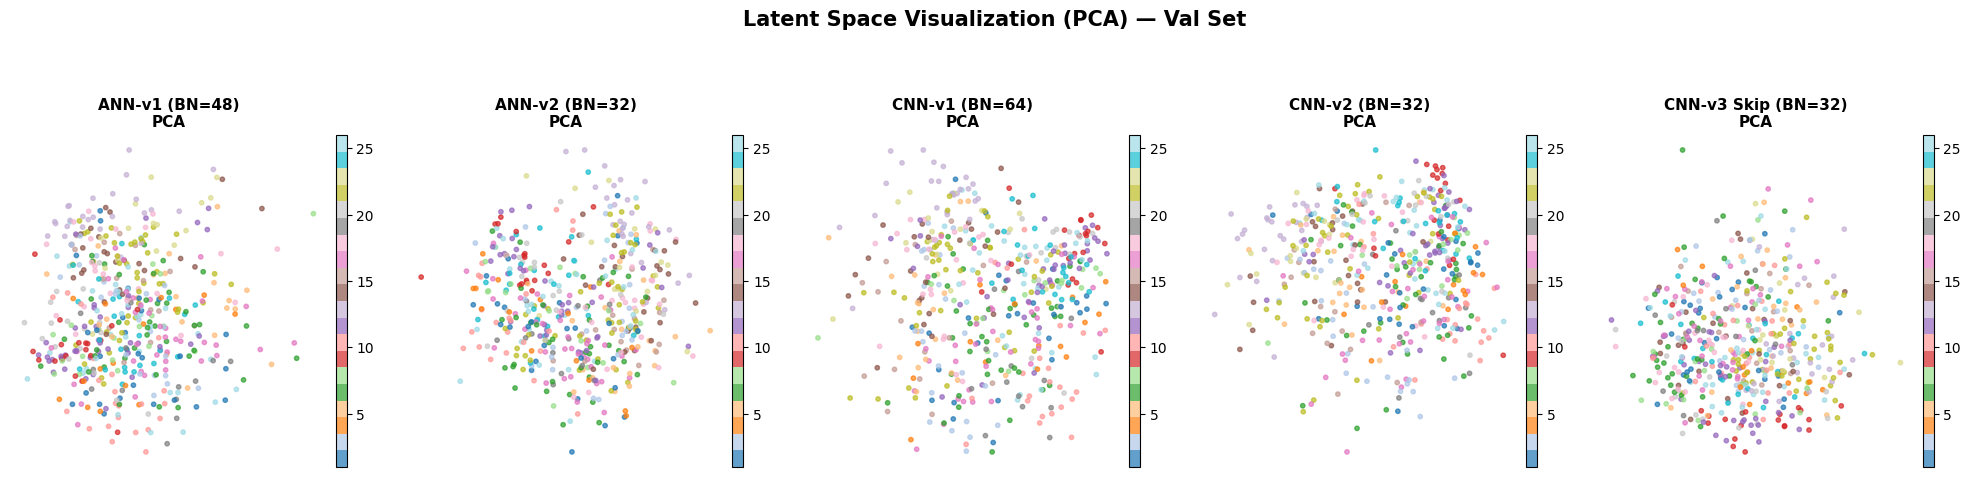

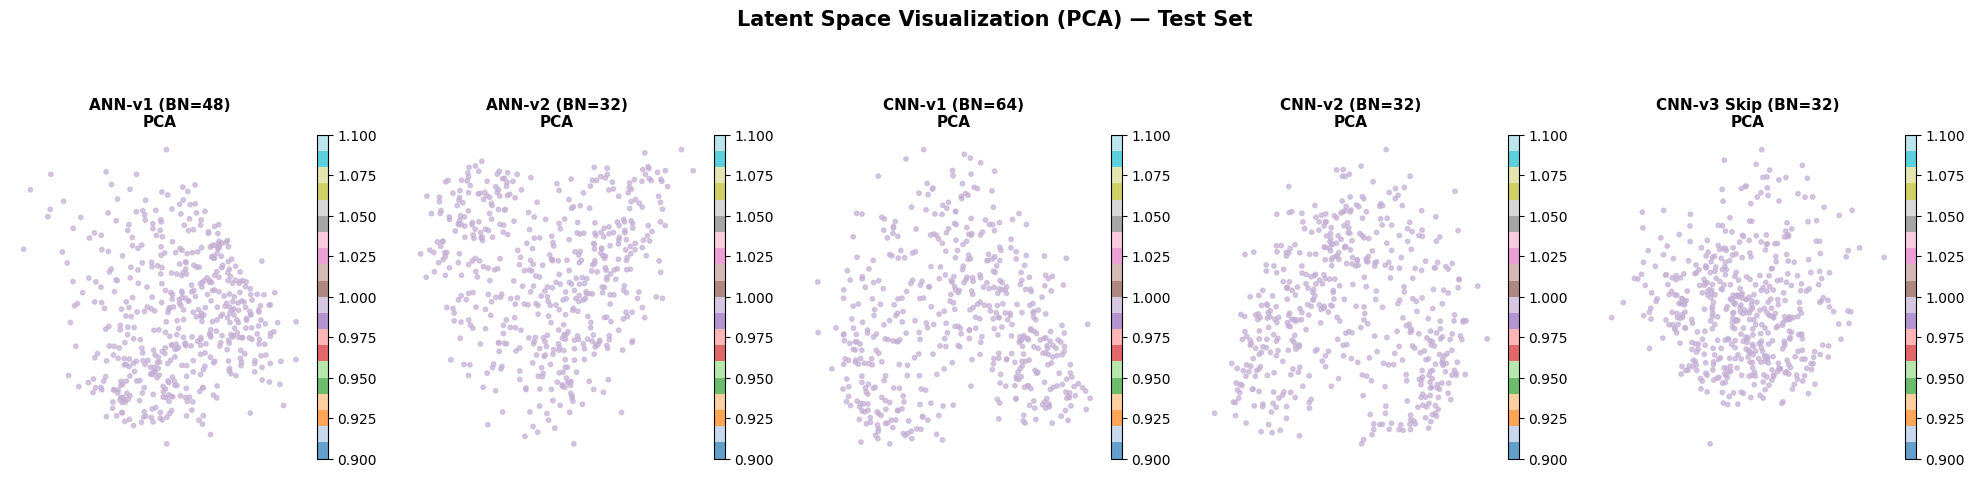

 Latent Space t-SNE 


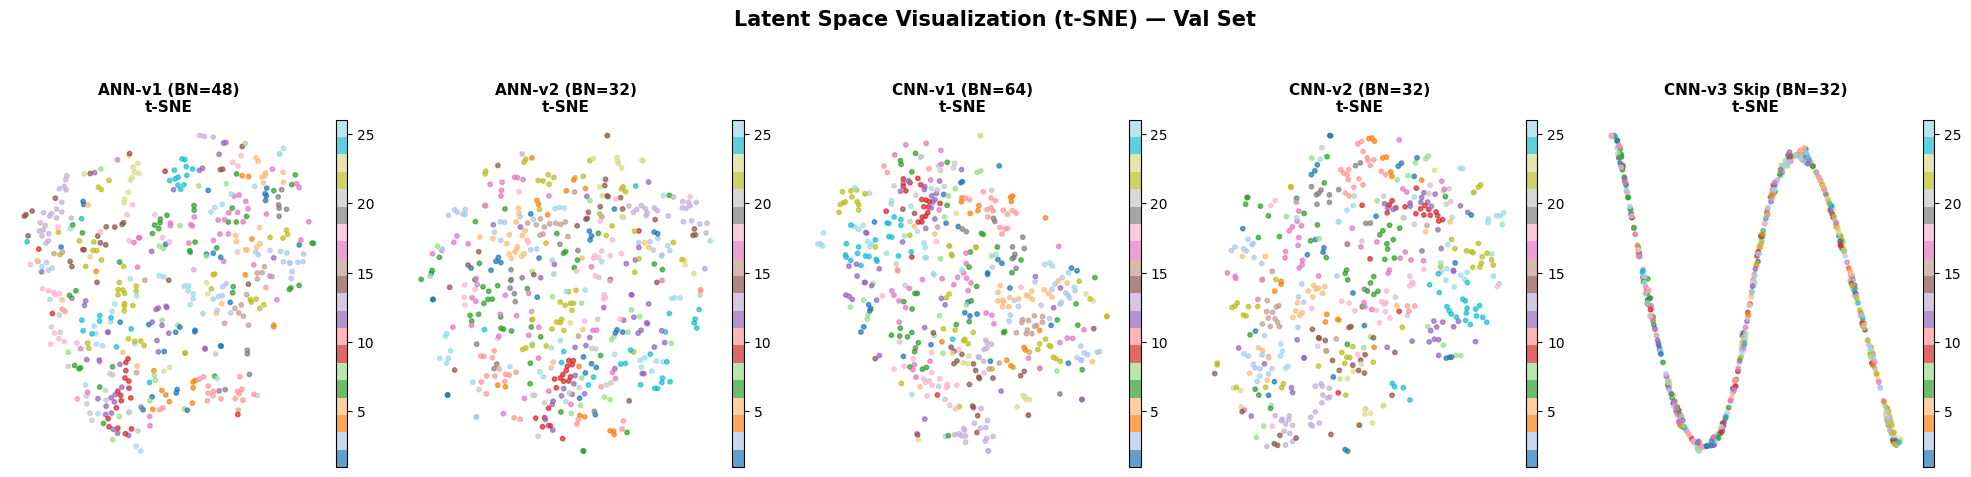

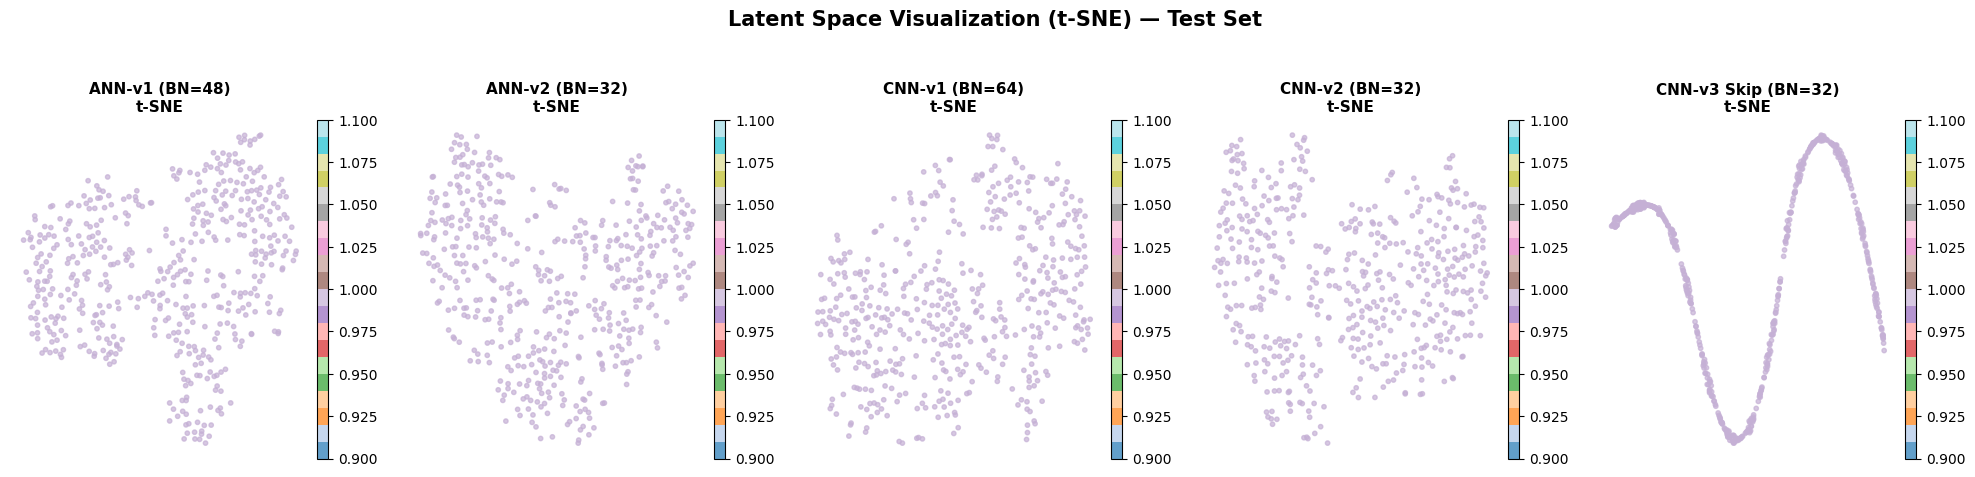

In [9]:
def get_latent_vectors(model, loader, max_samples=500):
    model.eval()
    latents, labels = [], []
    collected = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            
            z = model.encode(imgs).cpu().numpy()
            latents.append(z)
            labels.extend(lbls.numpy().tolist())
            collected += imgs.size(0)
            if collected >= max_samples:
                break
    return (np.concatenate(latents, axis=0)[:max_samples], 
            np.array(labels[:max_samples]))


def plot_latent_space(models_dict, loader, method='pca', split_name=''):
    n_models = len(models_dict)
    
   
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4.5))
    

    if n_models == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, models_dict.items()):
        Z, Y = get_latent_vectors(model, loader)

        # Dimensionality Reduction
        if method == 'tsne':
            # t-SNE is better for showing clusters but takes longer
            proj = TSNE(n_components=2, perplexity=min(30, len(Z)-1), 
                        random_state=SEED).fit_transform(Z)
            suffix = 't-SNE'
        else:
            # PCA is faster and shows linear variance
            proj = PCA(n_components=2, random_state=SEED).fit_transform(Z)
            suffix = 'PCA'

        # Scatter plot colored by true labels (classes)
        scatter = ax.scatter(proj[:, 0], proj[:, 1], c=Y, 
                             cmap='tab20', s=10, alpha=0.7)
        
        ax.set_title(f'{name}\n{suffix}', fontsize=11, fontweight='bold')
        ax.axis('off')
        
        # Add colorbar to each subplot to show class distribution
        plt.colorbar(scatter, ax=ax, pad=0.02, aspect=30)

    title = f'Latent Space Visualization ({suffix})'
    if split_name:
        title += f' — {split_name} Set'
        
    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    # Save the files for your SS folder
    fname = f'latent_{method}_{split_name.lower()}.png' if split_name else 'latent.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


# 1. PCA Comparison
print(' Latent Space PCA ')
plot_latent_space(models, val_loader,  method='pca',  split_name='Val')
plot_latent_space(models, test_loader, method='pca',  split_name='Test')

# 2. t-SNE Comparison
print(' Latent Space t-SNE ')
plot_latent_space(models, val_loader,  method='tsne', split_name='Val')
plot_latent_space(models, test_loader, method='tsne', split_name='Test')

## 8. Latent Space Interpolation

── Generative Latent Interpolation (Test Set) ──


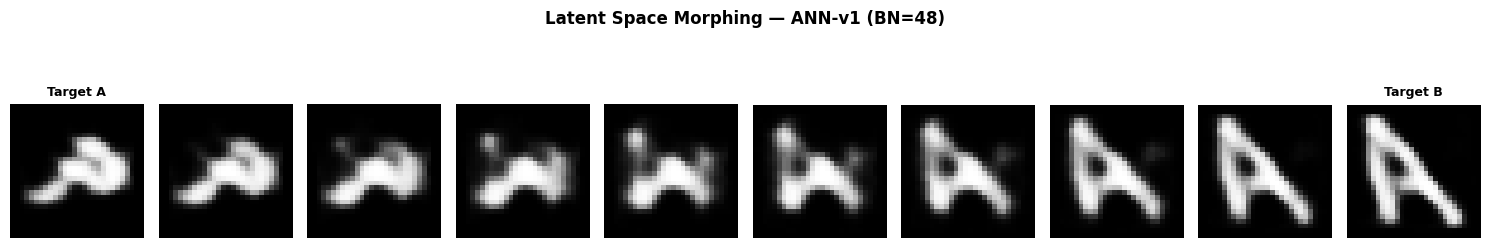

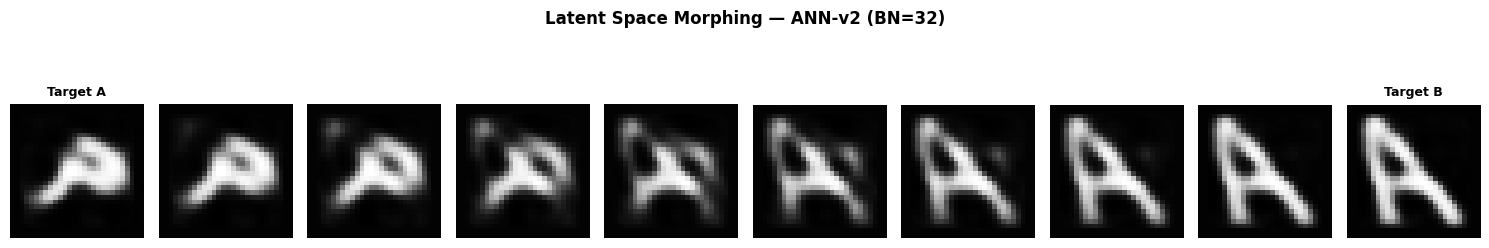

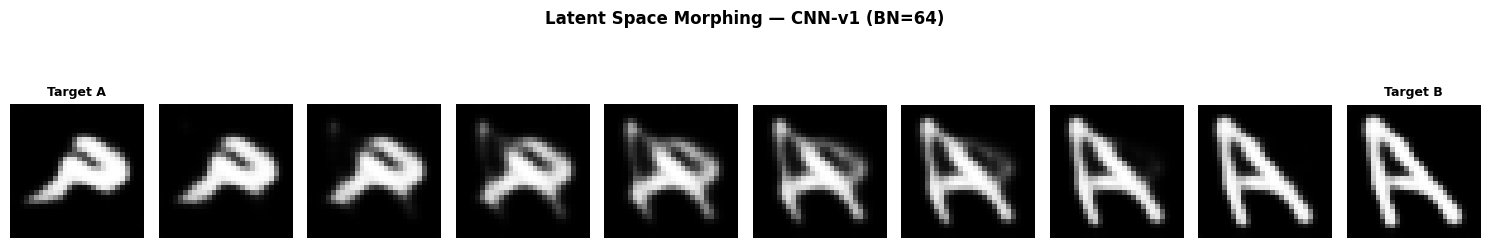

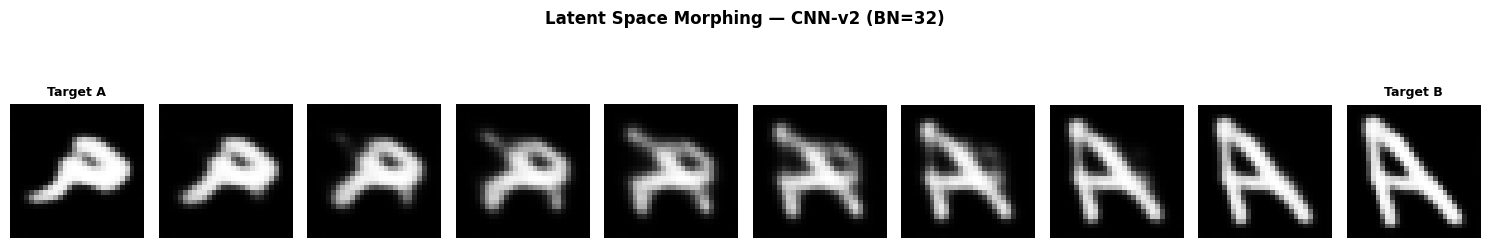

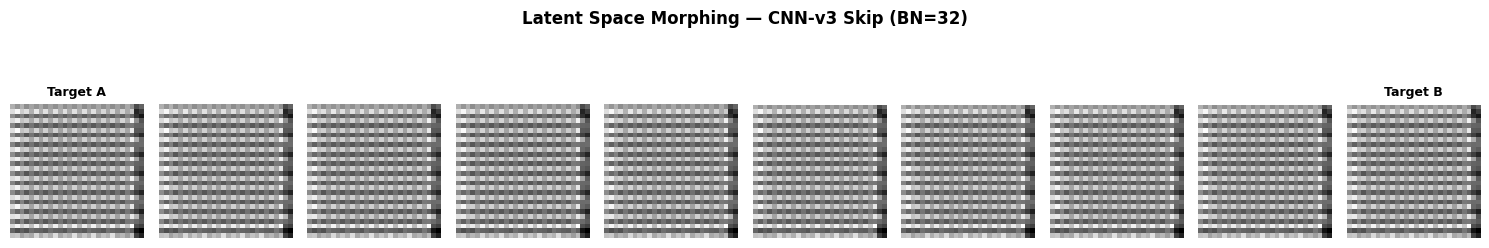

In [10]:
def interpolate_latent(model, loader, steps=10, model_name=''):
    
    model.eval()
    
   
    imgs, _ = next(iter(loader))
    img_a = imgs[0:1].to(DEVICE)
    img_b = imgs[1:2].to(DEVICE)

    with torch.no_grad():
        
        z_a = model.encode(img_a)
        z_b = model.encode(img_b)
        
        interps = []
        
        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * z_a + alpha * z_b
            # Reconstruct the 'fake' intermediate image
            recon = model.decode(z).cpu().clamp(0, 1)
            interps.append(recon)

  
    fig, axes = plt.subplots(1, steps, figsize=(steps * 1.5, 2.5))
    
    for ax, img in zip(axes, interps):
        ax.imshow(img[0].squeeze().numpy(), cmap='gray')
        ax.axis('off')
    
  
    axes[0].set_title('Target A', fontsize=9, fontweight='bold')
    axes[-1].set_title('Target B', fontsize=9, fontweight='bold')
    
    plt.suptitle(f'Latent Space Morphing — {model_name}', 
                 fontsize=12, fontweight='bold', y=1.08)
    plt.tight_layout()
    
    #
    safe = model_name.replace(' ', '_').replace('=', '').replace('(','').replace(')','') 
    plt.savefig(f'interpolation_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


print('── Generative Latent Interpolation (Test Set) ──')
for name, model in models.items():
    interpolate_latent(model, test_loader, steps=10, model_name=name)

## 9. Metrics — Validation & Test (MSE + PSNR)


Model                     Val MSE     Val PSNR   Test MSE    Test PSNR
------------------------------------------------------------------------
ANN-v1 (BN=48)           0.011565        19.40   0.011695        19.77
ANN-v2 (BN=32)           0.009379        20.31   0.009366        20.65
CNN-v1 (BN=64)           0.002120        26.77   0.002158        26.97
CNN-v2 (BN=32)           0.004432        23.58   0.004609        23.78
CNN-v3 Skip (BN=32)      0.000065        41.91   0.000065        41.96


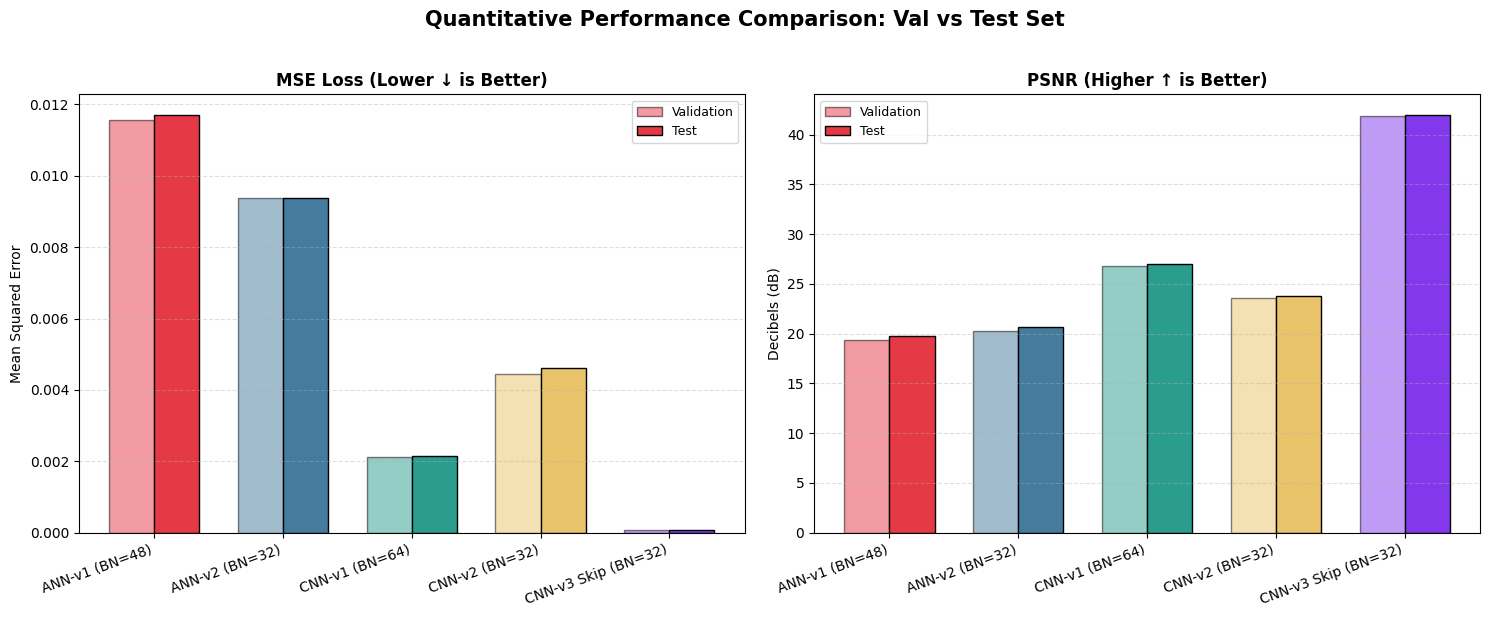

In [11]:
def psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return (20 * torch.log10(torch.tensor(1.0) / torch.sqrt(mse))).item()

@torch.no_grad()
def evaluate_metrics(model, loader):
    model.eval()
    total_mse, total_psnr, n = 0.0, 0.0, 0
    for imgs, _ in loader:
        imgs = imgs.to(DEVICE)
        recon, _ = model(imgs)
        recon = recon.clamp(0, 1)
        
        total_mse  += nn.MSELoss()(recon, imgs).item() * imgs.size(0)
        total_psnr += psnr(imgs, recon) * imgs.size(0)
        n += imgs.size(0)
    return total_mse / n, total_psnr / n

val_metrics  = {}
test_metrics = {}

print(f'\n{"Model":<22} {"Val MSE":>10} {"Val PSNR":>12} {"Test MSE":>10} {"Test PSNR":>12}')
print('-' * 72)

for name, model in models.items():
    vm, vp = evaluate_metrics(model, val_loader)
    tm, tp = evaluate_metrics(model, test_loader)
    val_metrics[name]  = (vm, vp)
    test_metrics[name] = (tm, tp)
    print(f'{name:<22} {vm:>10.6f} {vp:>12.2f} {tm:>10.6f} {tp:>12.2f}')

names = list(models.keys())
x     = np.arange(len(names))
w     = 0.35 # width of bars

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

val_mse   = [val_metrics[n][0]  for n in names]
test_mse  = [test_metrics[n][0] for n in names]
val_psnr  = [val_metrics[n][1]  for n in names]
test_psnr = [test_metrics[n][1] for n in names]

# MSE Plot 
axes[0].bar(x - w/2, val_mse,  w, label='Validation', color=COLORS, alpha=0.5, edgecolor='black')
axes[0].bar(x + w/2, test_mse, w, label='Test',       color=COLORS, alpha=1.0, edgecolor='black')
axes[0].set_title('MSE Loss (Lower ↓ is Better)', fontweight='bold')
axes[0].set_ylabel('Mean Squared Error')

# PSNR Plot 
axes[1].bar(x - w/2, val_psnr,  w, label='Validation', color=COLORS, alpha=0.5, edgecolor='black')
axes[1].bar(x + w/2, test_psnr, w, label='Test',       color=COLORS, alpha=1.0, edgecolor='black')
axes[1].set_title('PSNR (Higher ↑ is Better)', fontweight='bold')
axes[1].set_ylabel('Decibels (dB)')

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha='right')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Quantitative Performance Comparison: Val vs Test Set', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('val_vs_test_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Bottleneck Size Sweep (CNN-v1)


 Bottleneck = 16 
[CNN-v1-bn16] Epoch   1/15 | Train: 0.025418 | Val: 0.017260
[CNN-v1-bn16] Epoch   5/15 | Train: 0.013481 | Val: 0.013502
[CNN-v1-bn16] Epoch  10/15 | Train: 0.012592 | Val: 0.012627
[CNN-v1-bn16] Epoch  15/15 | Train: 0.012188 | Val: 0.012412
  → Best Val Loss: 0.012412


 Bottleneck = 32 
[CNN-v1-bn32] Epoch   1/15 | Train: 0.014838 | Val: 0.007337
[CNN-v1-bn32] Epoch   5/15 | Train: 0.005839 | Val: 0.005751
[CNN-v1-bn32] Epoch  10/15 | Train: 0.005581 | Val: 0.005633
[CNN-v1-bn32] Epoch  15/15 | Train: 0.005490 | Val: 0.005477
  → Best Val Loss: 0.005477


 Bottleneck = 48 
[CNN-v1-bn48] Epoch   1/15 | Train: 0.014216 | Val: 0.005053
[CNN-v1-bn48] Epoch   5/15 | Train: 0.003874 | Val: 0.003882
[CNN-v1-bn48] Epoch  10/15 | Train: 0.003668 | Val: 0.003653
[CNN-v1-bn48] Epoch  15/15 | Train: 0.003602 | Val: 0.003764
  → Best Val Loss: 0.003610


 Bottleneck = 64 
[CNN-v1-bn64] Epoch   1/15 | Train: 0.010173 | Val: 0.003771
[CNN-v1-bn64] Epoch   5/15 | Train: 0.003056

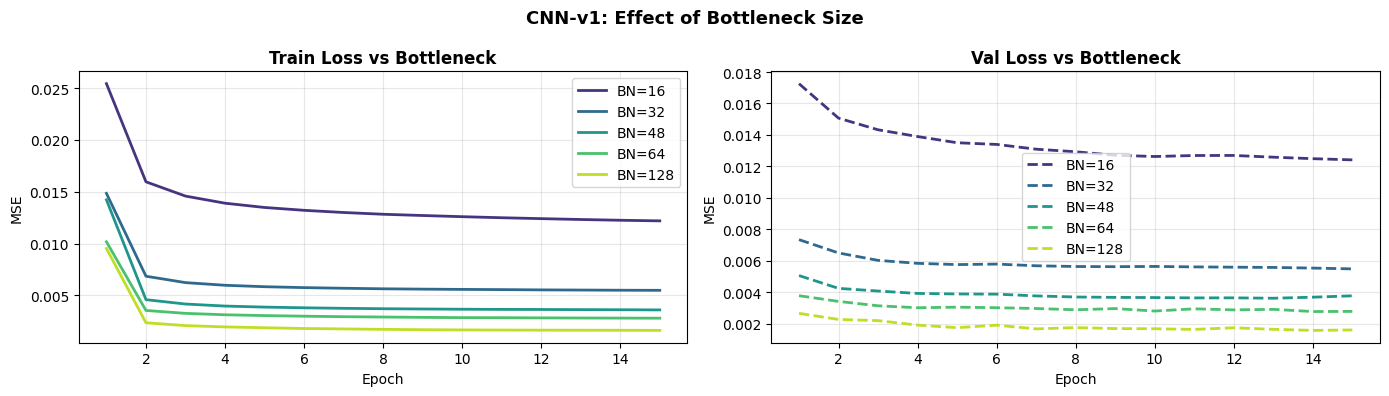

In [12]:
BOTTLENECK_SIZES = [16,32,48,64,128]
bn_results = {}

for bn in BOTTLENECK_SIZES:
    print(f'\n Bottleneck = {bn} ')
    m    = CNNAutoencoder_v1(bottleneck=bn).to(DEVICE)
    hist = train_model(m, train_loader, val_loader,
                       epochs=15, model_name=f'CNN-v1-bn{bn}')
    bn_results[bn] = hist

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette = plt.cm.viridis(np.linspace(0.15, 0.9, len(BOTTLENECK_SIZES)))

for (bn, hist), c in zip(bn_results.items(), palette):
    ep = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(ep, hist['train_loss'], color=c, label=f'BN={bn}', lw=2)
    axes[1].plot(ep, hist['val_loss'],   color=c, label=f'BN={bn}', lw=2, ls='--')

for ax, t in zip(axes, ['Train Loss vs Bottleneck', 'Val Loss vs Bottleneck']):
    ax.set_title(t, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('CNN-v1: Effect of Bottleneck Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bottleneck_sweep.png', dpi=150, bbox_inches='tight')
plt.show()